- salloc --partition gpu-vram-94gb --cpus-per-task=20 --mem=70G --gres=gpu:1 --time=10:00:00
- jupyter lab --no-browser --port=8888 --ip=0.0.0.0

# Main-Report Predictive Figures

This notebook regenerates the two main-report predictive figures from cached `01_mfa.ipynb` handoff artifacts:

- Figure 1: Leave-One-Dataset-Out MAE
- Figure 2: Leave-One-Dataset-Out Sign Accuracy

Set `PREDICTIVE_ESTIMATORS` to choose the predictive model used for the non-baseline variants. The paper default is `tabpfn`; `ridge`, `tree`, and `xgboost` are sensitivity checks reported in the appendix. MAE uses the continuous Mean Baseline; Sign Accuracy uses a separate training-only majority-sign baseline with exact training-sign ties broken toward the positive class. Models that handle missing values natively (TabPFN, XGBoost) are not pre-imputed; Ridge and Decision Tree use median imputation inside each fold.

In [28]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

try:
    from xgboost import XGBRegressor
except Exception:  # pragma: no cover - notebook convenience
    XGBRegressor = None

try:
    from tabpfn import TabPFNRegressor
except Exception:  # pragma: no cover - notebook convenience
    TabPFNRegressor = None


def torch_cuda_available() -> bool:
    try:
        import torch
    except ImportError:
        return False
    return bool(torch.cuda.is_available())


sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})

## Settings

Edit this cell when you want to compare Ridge, Decision Tree, XGBoost, or TabPFN. If you set several estimators, the notebook writes one MAE/Sign-Accuracy pair per estimator.

In [ ]:
cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    package_dir = cwd.parent
    repo_dir = package_dir.parent
elif cwd.name == "meta-feature-analysis":
    package_dir = cwd
    repo_dir = cwd.parent
else:
    repo_dir = cwd
    package_dir = repo_dir / "meta-feature-analysis"

handoff_root = package_dir / ".mfa_cache" / "notebook_handoff"
paper_figure_dir = repo_dir / "icml2026" / "figures"
paper_figure_dir.mkdir(parents=True, exist_ok=True)

# Main-report comparisons in display order.
MAIN_COMPARISONS = [
    {
        "label": "Non-TFM vs. TFM",
        "config_dir": "config_1_c4472762a9293af4",
    },
    {
        "label": "TabICL v2 vs TabPFN v2.6",
        "config_dir": "config_2_781b7f9c27428458",
    },
    {
        "label": "NN vs. Tree",
        "config_dir": "config_0_f025f9bfe1d83684",
    },
]

# Paper default: use the general matrix. Set to "analysis_classification_reduced" for the classification appendix.
ANALYSIS_TABLE = "analysis_general_reduced"

# Primary estimator for the paper figures. Ridge, tree, and xgboost are appendix sensitivity checks.
# Choose one or several: "tabpfn", "ridge", "tree", "xgboost".
PREDICTIVE_ESTIMATORS = ["tabpfn"]

# The estimator whose results are written to the canonical paper figure filenames.
PAPER_ESTIMATOR = "tabpfn"

# Predictor variants to show in each figure. Robust variants are skipped when no robust features are available.
PREDICTOR_SETS = [
    "mean_baseline",
    "controls",
    "meta_features",
    "controls_plus_meta",
    "robust_features",
    "controls_plus_robust",
]

EXPORT_FORMATS = ["pdf", "png"]
BOOTSTRAP_SAMPLES = 5000

TARGET = "delta_norm"
UNIT_COLUMN = "dataset"
RANDOM_STATE = 20260424
RIDGE_ALPHAS = np.logspace(-3, 3, 13)
TARGET_BOUNDS = (-1.0, 1.0)
CLIP_PREDICTIONS = True
TABPFN_DEVICE = "cuda" if torch_cuda_available() else "cpu"
if TabPFNRegressor is not None:
    print(f"TabPFN device: {TABPFN_DEVICE}")

GENERAL_CONTROLS = [
    "log_n",
    "log_d",
    "d_over_n",
    "cat_fraction",
    "feature_missing_fraction",
]
CLASSIFICATION_CONTROLS = ["n_classes", "class_imbalance_ratio"]

print(f"handoff_root: {handoff_root}")
print(f"paper_figure_dir: {paper_figure_dir}")

## Load cached analysis matrices

In [30]:
def load_analysis_table(config_dir: str, table_name: str) -> pd.DataFrame:
    path = handoff_root / config_dir / f"{table_name}.pkl"
    if not path.exists():
        raise FileNotFoundError(f"Missing handoff artifact: {path}")
    frame = pd.read_pickle(path).copy()
    if TARGET not in frame.columns:
        raise KeyError(f"{path} does not contain target column {TARGET!r}")
    if UNIT_COLUMN not in frame.columns:
        raise KeyError(f"{path} does not contain unit column {UNIT_COLUMN!r}")
    return frame


def robust_table_name_for_analysis(table_name: str) -> str:
    if "classification" in table_name:
        return "robust_classification_associations"
    return "robust_general_associations"


def load_optional_handoff_table(config_dir: str, table_name: str) -> pd.DataFrame:
    path = handoff_root / config_dir / f"{table_name}.pkl"
    if not path.exists():
        return pd.DataFrame()
    return pd.read_pickle(path).copy()


ROBUST_TABLE_NAME = robust_table_name_for_analysis(ANALYSIS_TABLE)

analysis_tables = {}
robust_tables = {}
for spec in MAIN_COMPARISONS:
    analysis_tables[spec["label"]] = load_analysis_table(
        spec["config_dir"], ANALYSIS_TABLE
    )
    robust_tables[spec["label"]] = load_optional_handoff_table(
        spec["config_dir"], ROBUST_TABLE_NAME
    )

pd.DataFrame(
    {
        "comparison": label,
        "rows": len(frame),
        "datasets": frame[UNIT_COLUMN].nunique(),
        "columns": frame.shape[1],
        "robust_features": (
            robust_tables[label]["feature"].nunique()
            if "feature" in robust_tables[label].columns
            else 0
        ),
    }
    for label, frame in analysis_tables.items()
)

,comparison,rows,datasets,columns,robust_features
0,Non-TFM vs. TFM,51,51,301,1
1,TabICL v2 vs TabPFN v2.6,51,51,301,1
2,NN vs. Tree,51,51,301,0


## Leave-one-dataset-out evaluation

In [ ]:
METADATA_COLUMNS = {
    UNIT_COLUMN,
    "task_type",
    "comparison_name",
    "group_a_name",
    "group_b_name",
    "group_a_label",
    "group_b_label",
    "expected_direction",
    "n_splits",
    "best_a_error",
    "best_a_norm_error",
    "best_b_error",
    "best_b_norm_error",
    "delta_raw",
    "delta_raw_std",
    "delta_raw_sem",
    "delta_norm",
    "delta_norm_std",
    "delta_norm_sem",
}

PREDICTOR_LABELS = {
    "mean_baseline": "Mean Baseline",
    "sign_majority_baseline": "Majority Sign Baseline",
    "controls": "Controls",
    "meta_features": "Meta-Features",
    "controls_plus_meta": "Controls + Meta-Features",
    "robust_features": "Robust Meta-Features",
    "controls_plus_robust": "Controls + Robust Meta-Features",
}

ESTIMATOR_LABELS = {
    "ridge": "Ridge",
    "tree": "Decision Tree",
    "xgboost": "XGBoost",
    "tabpfn": "TabPFN",
}


def controls_for_table(table_name: str, frame: pd.DataFrame) -> list[str]:
    controls = list(GENERAL_CONTROLS)
    if "classification" in table_name:
        controls += CLASSIFICATION_CONTROLS
    return [
        c
        for c in controls
        if c in frame.columns and pd.api.types.is_numeric_dtype(frame[c])
    ]


def meta_feature_columns(frame: pd.DataFrame, controls: list[str]) -> list[str]:
    excluded = METADATA_COLUMNS | set(controls)
    cols = []
    for col in frame.columns:
        if col in excluded:
            continue
        if not pd.api.types.is_numeric_dtype(frame[col]):
            continue
        if frame[col].notna().sum() < 2:
            continue
        if frame[col].nunique(dropna=True) < 2:
            continue
        cols.append(col)
    return cols


def robust_feature_columns(
    frame: pd.DataFrame, robust_table: pd.DataFrame | None, controls: list[str]
) -> list[str]:
    if (
        robust_table is None
        or robust_table.empty
        or "feature" not in robust_table.columns
    ):
        return []
    cols = []
    excluded = set(controls)
    for col in robust_table["feature"].dropna().astype(str):
        if col in excluded or col in cols or col not in frame.columns:
            continue
        if not pd.api.types.is_numeric_dtype(frame[col]):
            continue
        if frame[col].notna().sum() < 2:
            continue
        if frame[col].nunique(dropna=True) < 2:
            continue
        cols.append(col)
    return cols


def estimator_pipeline(estimator_name: str):
    if estimator_name == "ridge":
        # Ridge requires complete cases: impute then standardize inside each fold.
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", RidgeCV(alphas=RIDGE_ALPHAS, cv=None)),
            ]
        )
    if estimator_name == "tree":
        # Decision trees do not handle NaN natively in sklearn: impute inside each fold.
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    DecisionTreeRegressor(
                        max_depth=2,
                        min_samples_leaf=5,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
    if estimator_name == "xgboost":
        if XGBRegressor is None:
            raise ImportError("xgboost is not installed in this environment")
        # XGBoost handles missing values natively: no pre-imputation.
        return Pipeline(
            [
                (
                    "model",
                    XGBRegressor(
                        objective="reg:squarederror",
                        n_estimators=100,
                        max_depth=2,
                        learning_rate=0.05,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_lambda=10.0,
                        min_child_weight=5.0,
                        random_state=RANDOM_STATE,
                        n_jobs=1,
                    ),
                ),
            ]
        )
    if estimator_name == "tabpfn":
        if TabPFNRegressor is None:
            raise ImportError("tabpfn is not installed in this environment")
        # TabPFN handles missing values natively: no pre-imputation.
        return Pipeline(
            [
                (
                    "model",
                    TabPFNRegressor(
                        n_estimators=8,
                        device=TABPFN_DEVICE,
                        ignore_pretraining_limits=True,
                        random_state=RANDOM_STATE,
                        n_preprocessing_jobs=1,
                    ),
                ),
            ]
        )
    raise ValueError(f"Unknown estimator_name={estimator_name!r}")


def predictor_columns(
    frame: pd.DataFrame,
    predictor_set: str,
    controls: list[str],
    meta_cols: list[str],
    robust_cols: list[str],
) -> list[str]:
    if predictor_set in {"mean_baseline", "sign_majority_baseline"}:
        return []
    if predictor_set == "controls":
        return controls
    if predictor_set == "meta_features":
        return meta_cols
    if predictor_set == "controls_plus_meta":
        return controls + meta_cols
    if predictor_set == "robust_features":
        return robust_cols
    if predictor_set == "controls_plus_robust":
        return list(dict.fromkeys(controls + robust_cols))
    raise ValueError(f"Unknown predictor_set={predictor_set!r}")


def clip_target_prediction(value: float) -> float:
    if not CLIP_PREDICTIONS:
        return float(value)
    lower, upper = TARGET_BOUNDS
    return float(np.clip(value, lower, upper))


def majority_sign(y_train: np.ndarray) -> float:
    train_signs = np.sign(y_train.astype(float))
    train_signs = train_signs[train_signs != 0]
    majority = float(np.sign(train_signs.sum())) if len(train_signs) else 0.0
    if majority == 0:
        # Fixed tie-break avoids reverting the sign baseline to the continuous mean baseline.
        return 1.0
    return majority


def loodo_predictions(
    frame: pd.DataFrame,
    comparison: str,
    estimator_name: str,
    predictor_set: str,
    robust_table: pd.DataFrame | None = None,
) -> pd.DataFrame:
    frame = frame.loc[frame[TARGET].notna()].reset_index(drop=True)
    controls = controls_for_table(ANALYSIS_TABLE, frame)
    meta_cols = meta_feature_columns(frame, controls)
    robust_cols = robust_feature_columns(frame, robust_table, controls)
    features = predictor_columns(frame, predictor_set, controls, meta_cols, robust_cols)
    if predictor_set in {"robust_features", "controls_plus_robust"} and not robust_cols:
        return pd.DataFrame()
    rows = []

    for test_idx in range(len(frame)):
        train = frame.drop(index=test_idx)
        test = frame.iloc[[test_idx]]
        y_train = train[TARGET].astype(float).to_numpy()
        y_true = float(test[TARGET].iloc[0])

        if predictor_set == "mean_baseline":
            y_pred = float(np.mean(y_train))
        elif predictor_set == "sign_majority_baseline":
            y_pred = majority_sign(y_train)
        else:
            model = estimator_pipeline(estimator_name)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(train[features], y_train)
            y_pred = float(model.predict(test[features])[0])

        y_pred_raw = float(y_pred)
        y_pred = clip_target_prediction(y_pred_raw)
        absolute_error = abs(y_true - y_pred)
        if predictor_set == "sign_majority_baseline":
            absolute_error = np.nan

        rows.append(
            {
                "comparison": comparison,
                "estimator": estimator_name,
                "predictor_set": predictor_set,
                "predictor_label": PREDICTOR_LABELS[predictor_set],
                "dataset": test[UNIT_COLUMN].iloc[0],
                "n_predictors": len(features),
                "y_true": y_true,
                "y_pred": y_pred,
                "y_pred_raw": y_pred_raw,
                "y_pred_was_clipped": not np.isclose(y_pred, y_pred_raw),
                "absolute_error": absolute_error,
            }
        )
    return pd.DataFrame(rows)


def add_sign_accuracy(predictions: pd.DataFrame) -> pd.DataFrame:
    predictions = predictions.copy()
    true_sign = np.sign(predictions["y_true"])
    pred_sign = np.sign(predictions["y_pred"])
    predictions["sign_correct"] = (true_sign == pred_sign).astype(float)
    predictions.loc[true_sign == 0, "sign_correct"] = np.nan
    return predictions


def output_paths(estimator_name: str, metric: str) -> list[Path]:
    if metric not in {"mae", "sign_accuracy"}:
        raise ValueError(metric)
    stem = "predictive_mae_main" if metric == "mae" else "predictive_sign_accuracy_main"
    stems = []
    if estimator_name == PAPER_ESTIMATOR and ANALYSIS_TABLE == "analysis_general_reduced":
        stems.append(stem)
    stems.append(f"{stem}_{estimator_name}")
    return list(
        dict.fromkeys(
            paper_figure_dir / f"{s}.{fmt}"
            for s in stems
            for fmt in EXPORT_FORMATS
        )
    )

In [32]:
all_predictions = []
for estimator_name in PREDICTIVE_ESTIMATORS:
    for comparison, frame in analysis_tables.items():
        robust_table = robust_tables.get(comparison)
        all_predictions.append(
            loodo_predictions(
                frame=frame,
                comparison=comparison,
                estimator_name=estimator_name,
                predictor_set="sign_majority_baseline",
                robust_table=robust_table,
            )
        )
        for predictor_set in PREDICTOR_SETS:
            prediction_frame = loodo_predictions(
                frame=frame,
                comparison=comparison,
                estimator_name=estimator_name,
                predictor_set=predictor_set,
                robust_table=robust_table,
            )
            if not prediction_frame.empty:
                all_predictions.append(prediction_frame)

predictions = add_sign_accuracy(pd.concat(all_predictions, ignore_index=True))


def bootstrap_mean_ci(
    values: pd.Series, *, n_bootstrap: int = BOOTSTRAP_SAMPLES
) -> tuple[float, float]:
    values = values.dropna().astype(float).to_numpy()
    if len(values) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(RANDOM_STATE)
    boot = rng.choice(values, size=(n_bootstrap, len(values)), replace=True).mean(
        axis=1
    )
    return tuple(np.quantile(boot, [0.025, 0.975]))


summary_rows = []
for keys, group in predictions.groupby(
    ["estimator", "comparison", "predictor_set", "predictor_label"], sort=False
):
    estimator, comparison, predictor_set, predictor_label = keys
    mae_low, mae_high = bootstrap_mean_ci(group["absolute_error"])
    sign_low, sign_high = bootstrap_mean_ci(group["sign_correct"])
    summary_rows.append(
        {
            "estimator": estimator,
            "comparison": comparison,
            "predictor_set": predictor_set,
            "predictor_label": predictor_label,
            "n": group["dataset"].count(),
            "n_predictors": int(group["n_predictors"].iloc[0]),
            "n_clipped_predictions": int(group["y_pred_was_clipped"].sum()),
            "mae": group["absolute_error"].mean(),
            "mae_ci_low": mae_low,
            "mae_ci_high": mae_high,
            "sign_accuracy": group["sign_correct"].mean(),
            "sign_accuracy_ci_low": sign_low,
            "sign_accuracy_ci_high": sign_high,
        }
    )

summary = pd.DataFrame(summary_rows).sort_values(
    ["estimator", "comparison", "predictor_set"]
)
summary

,estimator,comparison,predictor_set,predictor_label,n,n_predictors,n_clipped_predictions,mae,mae_ci_low,mae_ci_high,sign_accuracy,sign_accuracy_ci_low,sign_accuracy_ci_high
16,tabpfn,NN vs. Tree,controls,Controls,51,5,0,0.207411,0.167378,0.249199,0.470588,0.333333,0.607843
18,tabpfn,NN vs. Tree,controls_plus_meta,Controls + Meta-Features,51,282,0,0.204572,0.164964,0.245304,0.529412,0.392157,0.666667
15,tabpfn,NN vs. Tree,mean_baseline,Mean Baseline,51,0,0,0.190860,0.151590,0.230670,0.549020,0.411765,0.686275
17,tabpfn,NN vs. Tree,meta_features,Meta-Features,51,277,0,0.205657,0.166758,0.245162,0.509804,0.372549,0.647059
14,tabpfn,NN vs. Tree,sign_majority_baseline,Majority Sign Baseline,51,0,0,NaN,NaN,NaN,0.549020,0.411765,0.686275
2,tabpfn,Non-TFM vs. TFM,controls,Controls,51,5,0,0.235092,0.186889,0.287088,0.803922,0.686275,0.901961
4,tabpfn,Non-TFM vs. TFM,controls_plus_meta,Controls + Meta-Features,51,282,0,0.251858,0.200706,0.309526,0.745098,0.627451,0.862745
6,tabpfn,Non-TFM vs. TFM,controls_plus_robust,Controls + Robust Meta-Features,51,6,0,0.209658,0.160582,0.263750,0.803922,0.686275,0.901961
1,tabpfn,Non-TFM vs. TFM,mean_baseline,Mean Baseline,51,0,0,0.240973,0.192374,0.295878,0.784314,0.666667,0.882353
3,tabpfn,Non-TFM vs. TFM,meta_features,Meta-Features,51,277,0,0.245673,0.194986,0.303391,0.745098,0.627451,0.862745


## Plot and export Figure 1 and Figure 2

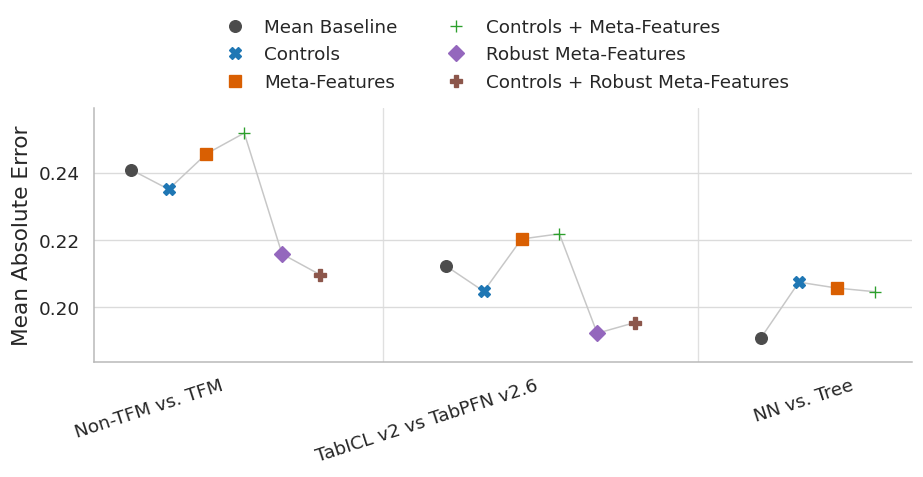

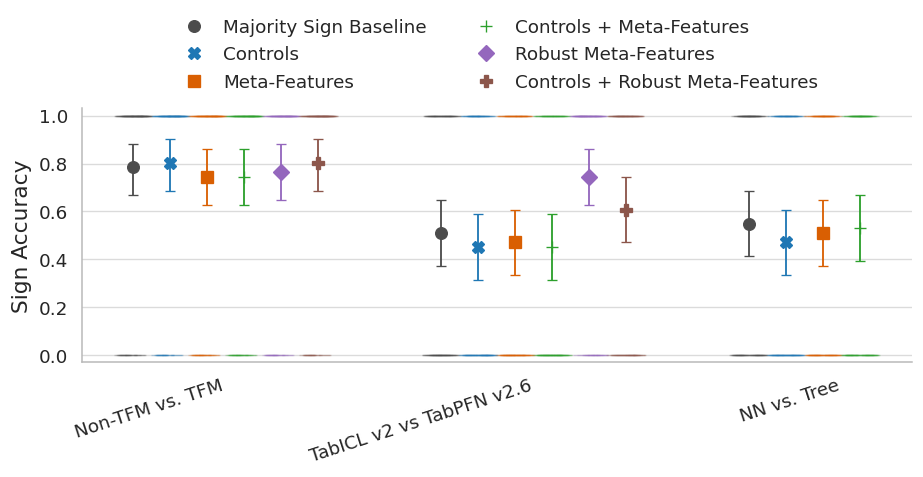

,saved_figure
0,/work/mherre/tabular-meta-feature-analysis/icm...
1,/work/mherre/tabular-meta-feature-analysis/icm...
2,/work/mherre/tabular-meta-feature-analysis/icm...
3,/work/mherre/tabular-meta-feature-analysis/icm...


In [35]:
comparison_order = [spec["label"] for spec in MAIN_COMPARISONS]
predictor_order = [PREDICTOR_LABELS[p] for p in PREDICTOR_SETS]
PLOT_MARKER_SIZE = 7.0
PLOT_MARKER_EDGE_WIDTH = 0.8
PLOT_AXIS_LABEL_SIZE = 13
PLOT_TICK_LABEL_SIZE = 11
PLOT_LEGEND_FONT_SIZE = 11
palette = {
    "Mean Baseline": "#4c4c4c",
    "Majority Sign Baseline": "#4c4c4c",
    "Controls": "#1f77b4",
    "Meta-Features": "#d95f02",
    "Controls + Meta-Features": "#2ca02c",
    "Robust Meta-Features": "#9467bd",
    "Controls + Robust Meta-Features": "#8c564b",
}
marker_styles = {
    "Mean Baseline": {
        "marker": "o",
        "markersize": PLOT_MARKER_SIZE,
        "linestyle": "none",
    },
    "Majority Sign Baseline": {
        "marker": "o",
        "markersize": PLOT_MARKER_SIZE,
        "linestyle": "none",
    },
    "Controls": {"marker": "X", "markersize": PLOT_MARKER_SIZE, "linestyle": "none"},
    "Meta-Features": {
        "marker": "s",
        "markersize": PLOT_MARKER_SIZE,
        "linestyle": "none",
    },
    "Controls + Meta-Features": {
        "marker": "+",
        "markersize": PLOT_MARKER_SIZE,
        "linestyle": "none",
    },
    "Robust Meta-Features": {
        "marker": "D",
        "markersize": PLOT_MARKER_SIZE,
        "linestyle": "none",
    },
    "Controls + Robust Meta-Features": {
        "marker": "P",
        "markersize": PLOT_MARKER_SIZE,
        "linestyle": "none",
    },
}


def output_paths(estimator_name: str, metric: str) -> list[Path]:
    if metric not in {"mae", "sign_accuracy"}:
        raise ValueError(metric)
    stem = "predictive_mae_main" if metric == "mae" else "predictive_sign_accuracy_main"
    stems = []
    if (
        estimator_name == "ridge"
        and ANALYSIS_TABLE == "analysis_general_reduced"
        and WRITE_PAPER_FILENAMES_FOR_RIDGE
    ):
        stems.append(stem)
    stems.append(f"{stem}_{estimator_name}")
    return list(
        dict.fromkeys(
            paper_figure_dir / f"{stem}.{fmt}"
            for stem in stems
            for fmt in EXPORT_FORMATS
        )
    )


def plot_metric(estimator_name: str, metric: str) -> tuple[plt.Figure, plt.Axes]:
    if metric == "mae":
        value_col = "mae"
        ylabel = "Mean Absolute Error"
    elif metric == "sign_accuracy":
        value_col = "sign_accuracy"
        ci_low_col = "sign_accuracy_ci_low"
        ci_high_col = "sign_accuracy_ci_high"
        ylabel = "Sign Accuracy"
    else:
        raise ValueError(metric)
    metric_predictor_sets = (
        ["sign_majority_baseline", *PREDICTOR_SETS[1:]]
        if metric == "sign_accuracy"
        else PREDICTOR_SETS
    )

    data = summary.loc[summary["estimator"].eq(estimator_name)].copy()
    available_labels = set(data["predictor_label"].dropna())
    metric_predictor_order = [
        PREDICTOR_LABELS[p]
        for p in metric_predictor_sets
        if PREDICTOR_LABELS[p] in available_labels
    ]
    data["comparison"] = pd.Categorical(
        data["comparison"], comparison_order, ordered=True
    )
    data["predictor_label"] = pd.Categorical(
        data["predictor_label"], metric_predictor_order, ordered=True
    )

    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    x_positions = np.arange(len(comparison_order), dtype=float)
    offset_span = 0.30 if len(metric_predictor_order) > 4 else 0.22
    offsets = np.linspace(-offset_span, offset_span, len(metric_predictor_order))
    handles = []

    if metric == "mae":
        for comparison_idx, comparison in enumerate(comparison_order):
            category = (
                data.loc[data["comparison"].eq(comparison)]
                .set_index("predictor_label")
                .reindex(metric_predictor_order)
            )
            ax.plot(
                x_positions[comparison_idx] + offsets,
                category[value_col].to_numpy(dtype=float),
                color="0.78",
                linewidth=0.9,
                zorder=1,
            )

    for predictor_label, offset in zip(metric_predictor_order, offsets, strict=True):
        subset = (
            data.loc[data["predictor_label"].eq(predictor_label)]
            .set_index("comparison")
            .reindex(comparison_order)
            .reset_index()
        )
        xs = x_positions + offset
        ys = subset[value_col].to_numpy(dtype=float)
        color = palette[predictor_label]
        if metric == "mae":
            marker_style = marker_styles[predictor_label]
            handle = ax.plot(
                xs,
                ys,
                color=color,
                markeredgecolor=color,
                markerfacecolor=color,
                markeredgewidth=PLOT_MARKER_EDGE_WIDTH,
                label=predictor_label,
                zorder=3,
                **marker_style,
            )[0]
        else:
            ci_low = subset[ci_low_col].to_numpy(dtype=float)
            ci_high = subset[ci_high_col].to_numpy(dtype=float)
            yerr = np.vstack(
                [np.maximum(ys - ci_low, 0.0), np.maximum(ci_high - ys, 0.0)]
            )
            marker_style = marker_styles[predictor_label]
            handle = ax.errorbar(
                xs,
                ys,
                yerr=yerr,
                fmt=marker_style["marker"],
                markersize=PLOT_MARKER_SIZE,
                capsize=3.0,
                elinewidth=1.1,
                markeredgewidth=PLOT_MARKER_EDGE_WIDTH,
                markeredgecolor=color,
                markerfacecolor=color,
                color=color,
                label=predictor_label,
                zorder=3,
            )
        handles.append(handle)

        if metric == "sign_accuracy":
            raw = predictions.loc[
                predictions["estimator"].eq(estimator_name)
                & predictions["predictor_label"].eq(predictor_label)
            ].copy()
            for comparison_idx, comparison in enumerate(comparison_order):
                raw_group = (
                    raw.loc[
                        raw["comparison"].eq(comparison), ["dataset", "sign_correct"]
                    ]
                    .dropna(subset=["sign_correct"])
                    .sort_values("dataset")
                )
                if len(raw_group) == 0:
                    continue
                point_offsets = (
                    np.linspace(-0.045, 0.045, len(raw_group))
                    if len(raw_group) > 1
                    else np.array([0.0])
                )
                ax.plot(
                    np.full(len(raw_group), x_positions[comparison_idx] + offset)
                    + point_offsets,
                    raw_group["sign_correct"].to_numpy(dtype=float),
                    linestyle="none",
                    marker="_",
                    markersize=PLOT_MARKER_SIZE,
                    markeredgewidth=PLOT_MARKER_EDGE_WIDTH,
                    alpha=0.28,
                    color=color,
                    zorder=2,
                )

    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.set_axisbelow(True)
    ax.grid(axis="y", which="major", color="0.86", linewidth=0.8)
    ax.grid(axis="y", which="minor", visible=False)
    ax.grid(axis="x", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("0.72")
    ax.spines["bottom"].set_color("0.72")
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(comparison_order, rotation=18, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=PLOT_AXIS_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=PLOT_TICK_LABEL_SIZE, color="0.72")

    if metric == "mae":
        mae_values = data[value_col].dropna().astype(float)
        if not mae_values.empty:
            mae_min = float(mae_values.min())
            mae_max = float(mae_values.max())
            mae_pad = 0.12 * (mae_max - mae_min) if mae_max > mae_min else 0.02
            ax.set_ylim(max(0.0, mae_min - mae_pad), mae_max + mae_pad)
        for separator in x_positions[:-1] + 0.5:
            ax.axvline(separator, color="0.88", linewidth=0.8, zorder=0)
    else:
        ax.set_ylim(-0.03, 1.03)
        ax.set_yticks(np.linspace(0.0, 1.0, 6))
        # ax.axhline(0.5, color="0.55", linestyle="--", linewidth=0.8, zorder=1)

    legend_handles = handles if metric == "mae" else [h.lines[0] for h in handles]
    ax.legend(
        handles=legend_handles,
        labels=metric_predictor_order,
        ncol=2,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.04),
        borderaxespad=0.0,
        columnspacing=2.2,
        handletextpad=0.6,
        fontsize=PLOT_LEGEND_FONT_SIZE,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    return fig, ax


saved_paths = []
for estimator_name in PREDICTIVE_ESTIMATORS:
    for metric in ["mae", "sign_accuracy"]:
        fig, _ = plot_metric(estimator_name, metric)
        for path in output_paths(estimator_name, metric):
            fig.savefig(path, bbox_inches="tight")
            saved_paths.append(path)
        plt.show()

pd.DataFrame({"saved_figure": [str(p) for p in saved_paths]})

## Paper-Ready Plots

Same figure dimensions as the main exports, with larger text and heavier visual elements for manuscript use.

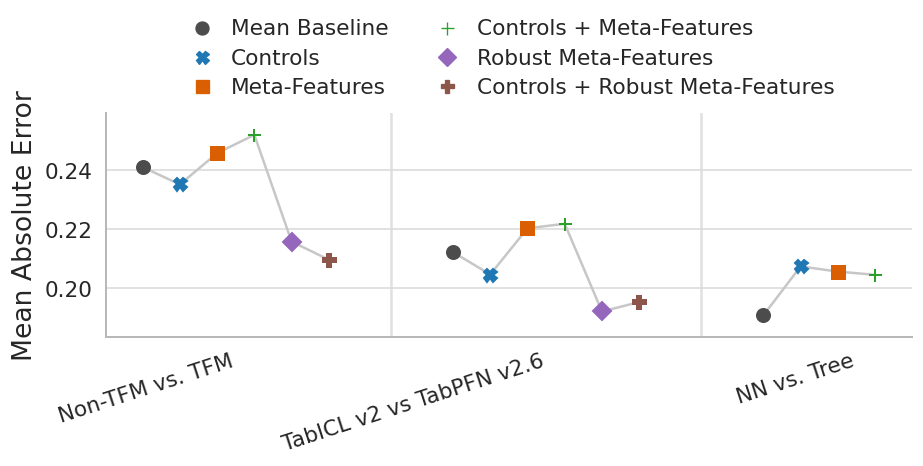

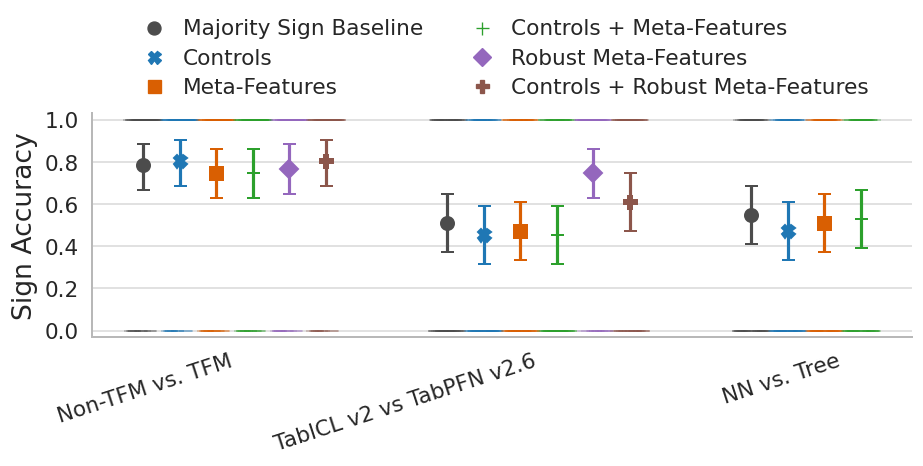

,saved_figure
0,/work/mherre/tabular-meta-feature-analysis/icm...
1,/work/mherre/tabular-meta-feature-analysis/icm...
2,/work/mherre/tabular-meta-feature-analysis/icm...
3,/work/mherre/tabular-meta-feature-analysis/icm...


In [36]:
PAPER_READY_STYLE = {
    "axis_label_size": 16,
    "tick_label_size": 13,
    "legend_font_size": 13,
    "marker_size": 7.8,
    "marker_edge_width": 1.2,
    "raw_marker_size": 7.8,
    "raw_marker_width": 1.2,
    "line_width": 1.5,
    "ci_line_width": 1.9,
    "spine_width": 1.2,
    "tick_width": 1.1,
    "tick_length": 4.5,
    "grid_width": 1.0,
}


def paper_ready_output_paths(estimator_name: str, metric: str) -> list[Path]:
    return [
        path.with_name(f"{path.stem}_paper_ready{path.suffix}")
        for path in output_paths(estimator_name, metric)
    ]


def apply_paper_ready_style(fig: plt.Figure, ax: plt.Axes) -> None:
    style = PAPER_READY_STYLE
    ax.xaxis.label.set_size(style["axis_label_size"])
    ax.yaxis.label.set_size(style["axis_label_size"])
    ax.tick_params(
        axis="both",
        labelsize=style["tick_label_size"],
        width=style["tick_width"],
        length=style["tick_length"],
    )

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(style["spine_width"])

    for gridline in ax.get_ygridlines():
        gridline.set_linewidth(style["grid_width"])

    for line in ax.lines:
        marker = line.get_marker()
        if marker == "_":
            line.set_markersize(style["raw_marker_size"])
            line.set_markeredgewidth(style["raw_marker_width"])
        elif marker not in {None, "", "None"}:
            line.set_markersize(style["marker_size"])
            line.set_markeredgewidth(style["marker_edge_width"])
        if line.get_linestyle() not in {"None", "none", ""}:
            line.set_linewidth(max(line.get_linewidth(), style["line_width"]))

    for collection in ax.collections:
        collection.set_linewidth(style["ci_line_width"])

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(style["legend_font_size"])
        legend_handles = getattr(legend, "legend_handles", None)
        if legend_handles is None:
            legend_handles = getattr(legend, "legendHandles", [])
        for handle in legend_handles:
            if hasattr(handle, "set_markersize"):
                handle.set_markersize(style["marker_size"])
            if hasattr(handle, "set_linewidth"):
                handle.set_linewidth(style["line_width"])

    fig.tight_layout(rect=(0, 0, 1, 0.87))


paper_ready_saved_paths = []
for estimator_name in PREDICTIVE_ESTIMATORS:
    for metric in ["mae", "sign_accuracy"]:
        fig, ax = plot_metric(estimator_name, metric)
        apply_paper_ready_style(fig, ax)
        for path in paper_ready_output_paths(estimator_name, metric):
            fig.savefig(path, bbox_inches="tight")
            paper_ready_saved_paths.append(path)
        plt.show()

pd.DataFrame({"saved_figure": [str(p) for p in paper_ready_saved_paths]})

## Interpretation guardrail

Use the MAE figure as the main predictive evidence. Sign Accuracy is diagnostic only: it can improve even when magnitude prediction gets worse, especially when the true gap direction is imbalanced.